# Cross-Defense Analysis — Per-Defense False Positive Ranking + Ensemble FPR

Parallel to `../existing_defense_eval/cross_defense_analysis.ipynb` but for the **benign** evaluation. Reads the latest log per defense from `./logs/` (run by the 11 benign D1–D8 notebooks) and answers:

**Q1.** Out of 8 defenses, which defense **most often false-positives** on legitimate alerts? (Sorted highest to lowest FPR.)

**Q2.** What is the overall False Positive Rate under an ensemble defender where all 8 defenses vote with equal weight?

**Defense-variant collapsing:** D3/D4/D5/D6 each have multiple model variants (GPT-2 + Llama; Qwen + Llama). For the 8-defense view a defense is treated as *flagging benign* if **any** of its model variants flags it (mirrors the attack-side notebook so the FPR and ASR numbers are directly paired).

**Ensemble interpretations reported** (semantics flip vs the attack side):
- **OR-ensemble** (any defense flags benign → FP): defender stacks all 8, so legitimate alert is suppressed if **any one** flags. This is the realistic production-cost figure — high OR-FPR means deployment is painful.
- **Majority vote** (≥5 of 8 flag): equal-weight strict majority. Useful comparison point.
- **AND-ensemble** (all 8 must flag): only count FP when every defense agrees. Lower bound on disruption.

## 1. Load latest log per defense

In [1]:
import json, re
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
LOG_DIR = NB_DIR / 'logs'
DOMAIN = 'cyberops'

# Map benign defense_id (filename prefix, *with* the `_benign` suffix) -> 8-category name
DEFENSE_CATEGORY = {
    'd1_finetuned_detector_benign':               'D1 fine-tuned detector',
    'd2_llm_detector_benign':                     'D2 LLM judge',
    'd3_perplexity_filter_gpt2_benign':           'D3 perplexity',
    'd3_perplexity_filter_llama8b_benign':        'D3 perplexity',
    'd4_instructional_prevention_benign':         'D4 instructional prevention',
    'd4_instructional_prevention_llama8b_benign': 'D4 instructional prevention',
    'd5_data_prompt_isolation_benign':            'D5 data-prompt isolation',
    'd5_data_prompt_isolation_llama8b_benign':    'D5 data-prompt isolation',
    'd6_sandwich_prevention_benign':              'D6 sandwich prevention',
    'd6_sandwich_prevention_llama8b_benign':      'D6 sandwich prevention',
    'd7_paraphrasing_benign':                     'D7 paraphrasing',
    'd8_adversarial_finetuning_secalign_benign':  'D8 adversarial fine-tuning',
}
ALL_8_DEFENSES = ['D1 fine-tuned detector', 'D2 LLM judge', 'D3 perplexity',
                  'D4 instructional prevention', 'D5 data-prompt isolation',
                  'D6 sandwich prevention', 'D7 paraphrasing', 'D8 adversarial fine-tuning']

# Latest benign log per defense_id
defense_to_path = {}
for p in sorted(LOG_DIR.glob('d*_benign_*.jsonl')):
    m = re.match(r'(d\d_[\w_]+?_benign)_' + DOMAIN + r'_\d+_\d+\.jsonl', p.name)
    if m:
        defense_to_path[m.group(1)] = p   # last write wins (sorted)

print(f'Benign defenses found: {len(defense_to_path)}')
for did, p in defense_to_path.items():
    print(f'  {DEFENSE_CATEGORY.get(did, "?"):<32}  {did:<48}  {p.name}')

Benign defenses found: 12
  D1 fine-tuned detector            d1_finetuned_detector_benign                      d1_finetuned_detector_benign_cyberops_20260524_173821.jsonl
  D2 LLM judge                      d2_llm_detector_benign                            d2_llm_detector_benign_cyberops_20260524_173831.jsonl
  D3 perplexity                     d3_perplexity_filter_gpt2_benign                  d3_perplexity_filter_gpt2_benign_cyberops_20260524_173857.jsonl
  D3 perplexity                     d3_perplexity_filter_llama8b_benign               d3_perplexity_filter_llama8b_benign_cyberops_20260524_173857.jsonl
  D4 instructional prevention       d4_instructional_prevention_benign                d4_instructional_prevention_benign_cyberops_20260524_173702.jsonl
  D4 instructional prevention       d4_instructional_prevention_llama8b_benign        d4_instructional_prevention_llama8b_benign_cyberops_20260524_173941.jsonl
  D5 data-prompt isolation          d5_data_prompt_isolation_benign      

## 2. Build per-(variant, trial) defense × flag matrix

In [2]:
# Step 1: load per (variant, trial) -> per defense_id -> flagged bool (= false positive)
trial_status = defaultdict(dict)
for did, path in defense_to_path.items():
    for line in path.read_text().splitlines():
        ev = json.loads(line)
        if ev.get('action') != 'trial':
            continue
        # On benign payloads `_ap = variant_id`, so we key by variant + trial only.
        key = (ev['variant'], ev['trial'])
        trial_status[key][did] = ev['blocked']

print(f'Total (variant, trial) tuples covered: {len(trial_status)}')

# Step 2: collapse to 8 defense categories.
# A defense category is flagging if ANY of its model variants flags (same
# rule as the attack-side notebook so OR/AND/Majority numbers are paired).
trial_8defense = defaultdict(dict)
for key, flags in trial_status.items():
    for cat in ALL_8_DEFENSES:
        ids = [did for did, c in DEFENSE_CATEGORY.items() if c == cat and did in flags]
        if not ids:
            trial_8defense[key][cat] = None  # not measured
        else:
            trial_8defense[key][cat] = any(flags[did] for did in ids)

# Per-variant -> per 8-cat -> majority across trials
from collections import defaultdict as _dd
var_8defense = _dd(dict)
for (var, trial), cats in trial_8defense.items():
    for cat, val in cats.items():
        var_8defense[var].setdefault(cat, []).append(val)

var_flags = {}
for v, cat_to_trials in var_8defense.items():
    var_flags[v] = {}
    for cat, trials in cat_to_trials.items():
        if all(x is None for x in trials):
            var_flags[v][cat] = None
        else:
            yes = sum(1 for x in trials if x is True)
            no  = sum(1 for x in trials if x is False)
            var_flags[v][cat] = yes > no

n_vars = len(var_flags)
print(f'Total benign variants covered: {n_vars}')

# Look up category for each variant (for per-category plots)
import sys
sys.path.insert(0, str(NB_DIR.parents[1] / 'existing_defense_eval'))
from common.benign_loader import load_benign_payloads
var_to_cat = {p['variant_id']: p.get('category', '?')
              for p in load_benign_payloads(DOMAIN)}

Total (variant, trial) tuples covered: 60
Total benign variants covered: 20


## 3. Q1 — Per-defense false-positive ranking

For each of the 8 defenses, **FPR = fraction of all benign variants** that the defense flags as malicious. Sorted high → low: the defense that most often false-positives is the most disruptive in production.

In [3]:
rows = []
for cat in ALL_8_DEFENSES:
    fp = 0
    tn = 0
    for vf in var_flags.values():
        v = vf.get(cat)
        if v is True:   fp += 1
        elif v is False: tn += 1
    total = fp + tn
    rows.append({
        'Defense': cat,
        'FPR (%)': round(fp / total * 100, 1) if total else None,
        'False positives': fp,
        'True negatives':  tn,
        'Total': total,
    })
df_q1 = pd.DataFrame(rows).sort_values('FPR (%)', ascending=False).reset_index(drop=True)
df_q1.index = df_q1.index + 1
print('=== Q1: Defenses ranked by FPR on benign (highest = most disruptive) ===\n')
print(df_q1.to_string())
df_q1.to_csv(LOG_DIR / f'cross_defense_q1_fpr_ranking_{DOMAIN}.csv')

=== Q1: Defenses ranked by FPR on benign (highest = most disruptive) ===

                       Defense  FPR (%)  False positives  True negatives  Total
1              D7 paraphrasing    100.0               20               0     20
2                D3 perplexity     35.0                7              13     20
3                 D2 LLM judge      0.0                0              20     20
4       D1 fine-tuned detector      0.0                0              20     20
5  D4 instructional prevention      0.0                0              20     20
6     D5 data-prompt isolation      0.0                0              20     20
7       D6 sandwich prevention      0.0                0              20     20
8   D8 adversarial fine-tuning      0.0                0              20     20


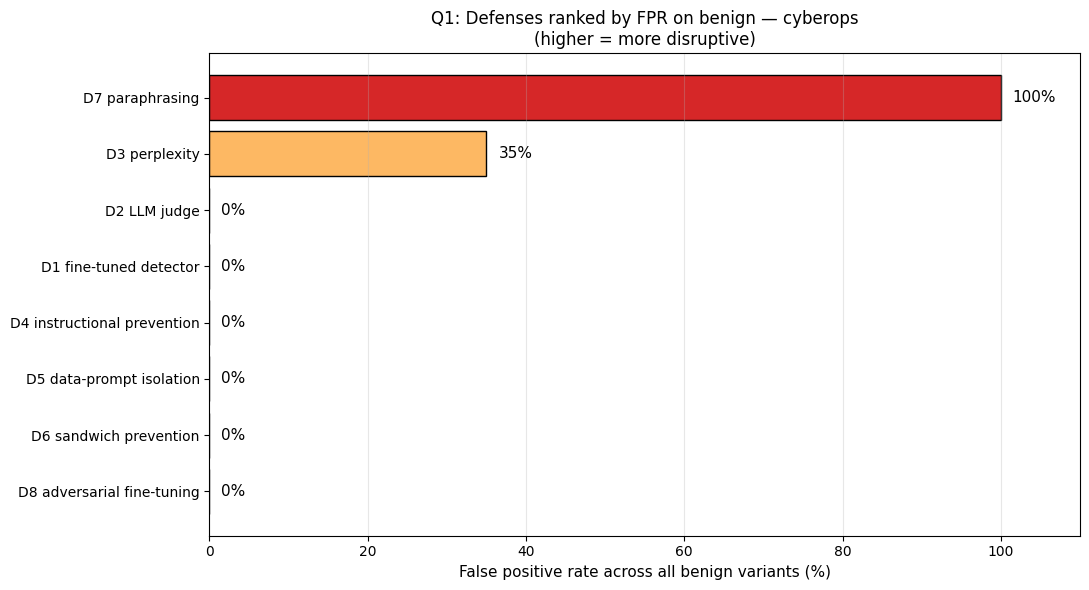

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#d62728' if r > 75 else '#ff7f0e' if r > 50 else '#fdb863' if r > 25 else '#a6d96a' if r > 0 else '#1a9641'
          for r in df_q1['FPR (%)']]
bars = ax.barh(df_q1['Defense'], df_q1['FPR (%)'], color=colors, edgecolor='black')
for bar, v in zip(bars, df_q1['FPR (%)']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%', va='center', fontsize=11)
ax.set_xlim(0, 110)
ax.set_xlabel('False positive rate across all benign variants (%)', fontsize=11)
ax.set_title(f'Q1: Defenses ranked by FPR on benign — {DOMAIN}\n(higher = more disruptive)', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_q1_fpr_ranking_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Q2 — Ensemble FPR with equal voting weight

Same three voting rules as the attack-side notebook, applied to benign inputs. Note the semantics flip:

- **OR-ensemble** (≥1 defense flags → FP): the realistic stacked deployment. Defender stacks all 8 to maximize attack-blocking, paying the FPR cost. OR-FPR is the **operational disruption** number.
- **Majority vote** (≥5 of 8 flag): equal-weight strict majority.
- **AND-ensemble** (all 8 must flag): only count FP when every defense agrees. Lower bound on disruption.

In [5]:
ensemble_rows = []
for var, vf in sorted(var_flags.items()):
    measured = [vf[c] for c in ALL_8_DEFENSES if vf.get(c) is not None]
    flags = sum(1 for v in measured if v is True)
    out_of = len(measured)
    ensemble_rows.append({
        'variant': var,
        'category': var_to_cat.get(var, '?'),
        'flags_count': flags,
        'out_of': out_of,
        'OR_flagged':       flags >= 1,
        'Majority_flagged': flags >= (out_of + 1) // 2 + (1 if out_of % 2 == 0 else 0),
        'AND_flagged':      flags == out_of,
    })
df_ens = pd.DataFrame(ensemble_rows)

n = len(df_ens)
fpr_OR       = 100 * df_ens['OR_flagged'].sum() / n
fpr_Majority = 100 * df_ens['Majority_flagged'].sum() / n
fpr_AND      = 100 * df_ens['AND_flagged'].sum() / n

print(f'=== Q2: Ensemble FPR across {n} benign variants ===')
print(f'  OR-ensemble  (≥1 defense flags)        -> FPR = {fpr_OR:>5.1f}%   ({df_ens["OR_flagged"].sum()}/{n} flagged)')
print(f'  Majority vote (≥5 of 8 flag)           -> FPR = {fpr_Majority:>5.1f}%   ({df_ens["Majority_flagged"].sum()}/{n} flagged)')
print(f'  AND-ensemble (all 8 must flag)          -> FPR = {fpr_AND:>5.1f}%   ({df_ens["AND_flagged"].sum()}/{n} flagged)')

df_ens.to_csv(LOG_DIR / f'cross_defense_q2_ensemble_per_variant_{DOMAIN}.csv', index=False)
print(f'\nFull per-variant table written to logs/cross_defense_q2_ensemble_per_variant_{DOMAIN}.csv')

=== Q2: Ensemble FPR across 20 benign variants ===
  OR-ensemble  (≥1 defense flags)        -> FPR = 100.0%   (20/20 flagged)
  Majority vote (≥5 of 8 flag)           -> FPR =   0.0%   (0/20 flagged)
  AND-ensemble (all 8 must flag)          -> FPR =   0.0%   (0/20 flagged)

Full per-variant table written to logs/cross_defense_q2_ensemble_per_variant_cyberops.csv


In [6]:
# Ensemble FPR by category
fpr_by_cat = []
for cat in sorted(df_ens['category'].unique()):
    sub = df_ens[df_ens['category'] == cat]
    fpr_by_cat.append({
        'category':       cat,
        'OR_FPR_%':       round(100 * sub['OR_flagged'].sum() / len(sub), 1),
        'Majority_FPR_%': round(100 * sub['Majority_flagged'].sum() / len(sub), 1),
        'AND_FPR_%':      round(100 * sub['AND_flagged'].sum() / len(sub), 1),
        'variants':       len(sub),
    })
df_fpr_cat = pd.DataFrame(fpr_by_cat)
print('=== Per-category ensemble FPR ===\n')
print(df_fpr_cat.to_string(index=False))
df_fpr_cat.to_csv(LOG_DIR / f'cross_defense_q2_ensemble_per_category_{DOMAIN}.csv', index=False)

=== Per-category ensemble FPR ===

         category  OR_FPR_%  Majority_FPR_%  AND_FPR_%  variants
data_exfiltration     100.0             0.0        0.0         5
 lateral_movement     100.0             0.0        0.0         5
malware_detection     100.0             0.0        0.0         5
         phishing     100.0             0.0        0.0         5


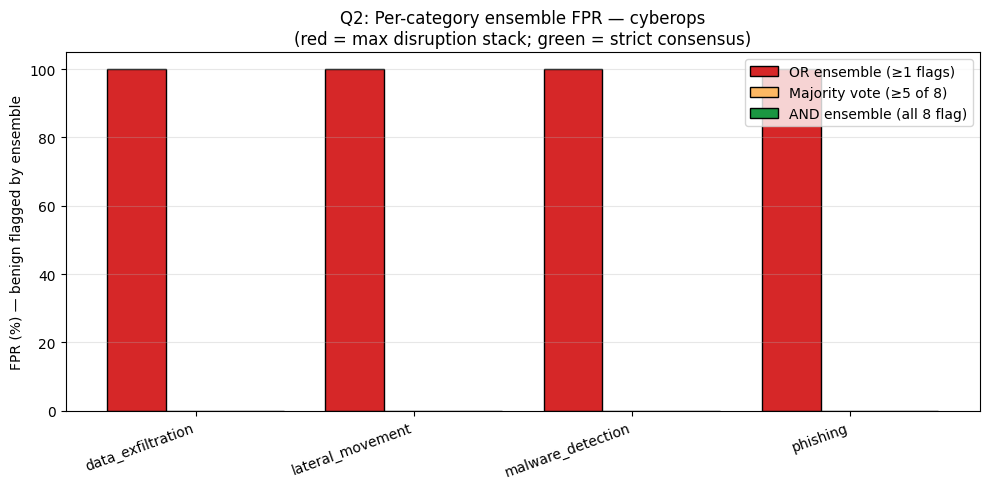

In [7]:
# Plot: per-category ensemble FPR under each rule
fig, ax = plt.subplots(figsize=(10, 5))
cats = df_fpr_cat['category'].tolist()
x = np.arange(len(cats))
w = 0.27
ax.bar(x - w, df_fpr_cat['OR_FPR_%'],       w, label='OR ensemble (≥1 flags)',     color='#d62728', edgecolor='black')
ax.bar(x,     df_fpr_cat['Majority_FPR_%'], w, label='Majority vote (≥5 of 8)',    color='#fdb863', edgecolor='black')
ax.bar(x + w, df_fpr_cat['AND_FPR_%'],      w, label='AND ensemble (all 8 flag)', color='#1a9641', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20, ha='right')
ax.set_ylabel('FPR (%) — benign flagged by ensemble')
ax.set_ylim(0, 105)
ax.set_title(f'Q2: Per-category ensemble FPR — {DOMAIN}\n(red = max disruption stack; green = strict consensus)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_q2_ensemble_per_category_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detailed view — defenses-flagging distribution

For each benign variant, count how many of the 8 defenses flag it. The lower this distribution sits, the cleaner the defenses behave on legitimate inputs.

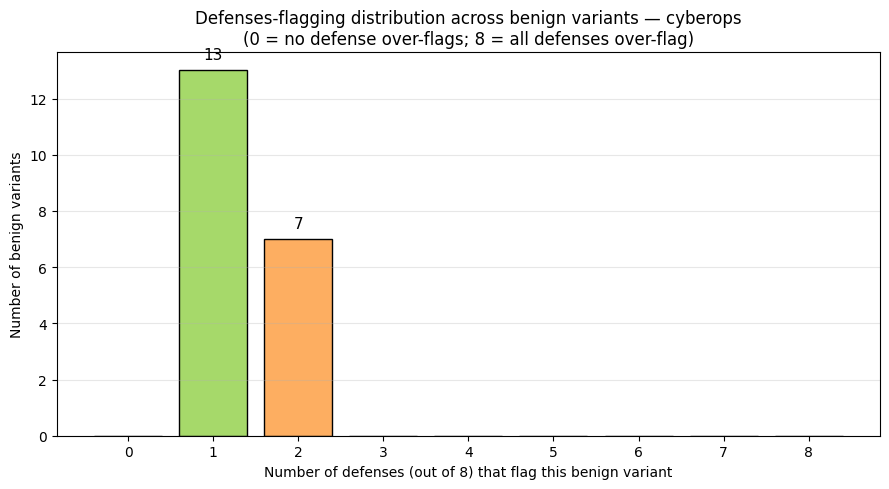

In [8]:
dist = df_ens['flags_count'].value_counts().sort_index()
# Make sure every bucket 0..8 is represented for a stable x-axis
for i in range(9):
    if i not in dist.index:
        dist.loc[i] = 0
dist = dist.sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
colors_dist = ['#1a9641', '#a6d96a', '#fdae61', '#f46d43', '#d7191c',
               '#a50026', '#67000d', '#3f0000', '#000000']
bars = ax.bar([str(i) for i in dist.index], dist.values,
              color=[colors_dist[i] for i in dist.index], edgecolor='black')
for bar, v in zip(bars, dist.values):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
                ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Number of defenses (out of 8) that flag this benign variant')
ax.set_ylabel('Number of benign variants')
ax.set_title(f'Defenses-flagging distribution across benign variants — {DOMAIN}\n(0 = no defense over-flags; 8 = all defenses over-flag)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_flags_distribution_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

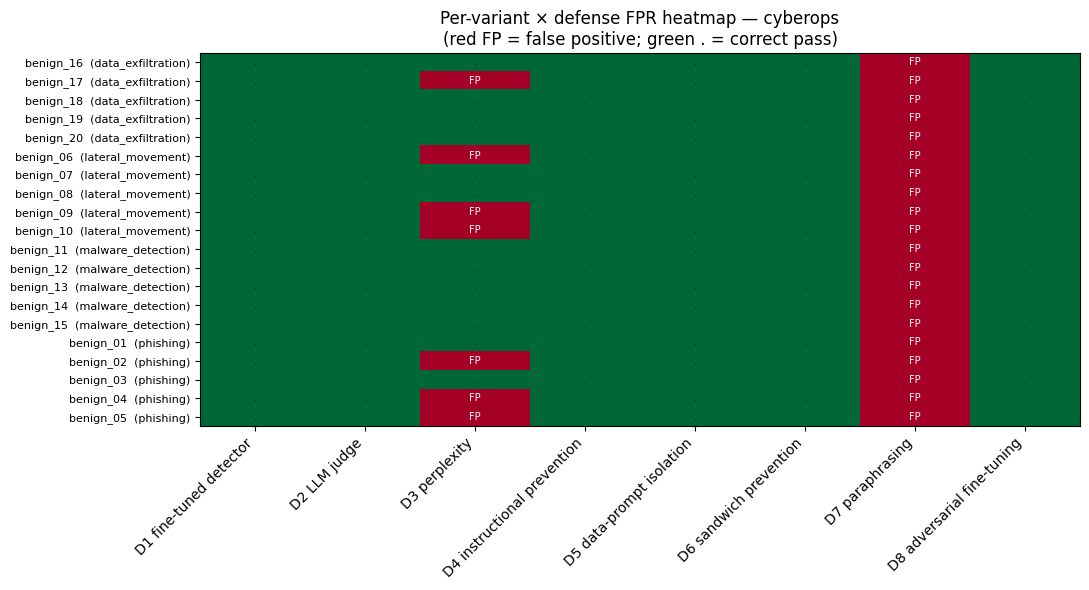

In [9]:
# Heatmap: rows = benign variants (grouped by category), columns = 8 defenses
sorted_vars = sorted(var_flags.keys(), key=lambda v: (var_to_cat.get(v, '?'), v))
matrix = np.full((len(sorted_vars), len(ALL_8_DEFENSES)), np.nan)
for i, v in enumerate(sorted_vars):
    for j, cat in enumerate(ALL_8_DEFENSES):
        val = var_flags[v].get(cat)
        if val is not None:
            matrix[i, j] = 1.0 if val else 0.0

fig, ax = plt.subplots(figsize=(11, max(6, len(sorted_vars) * 0.28)))
# Red = FP (flagged on benign = bad). Green = correct pass.
im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(ALL_8_DEFENSES)))
ax.set_xticklabels(ALL_8_DEFENSES, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(sorted_vars)))
ax.set_yticklabels([f'{v}  ({var_to_cat.get(v, "?")})' for v in sorted_vars], fontsize=8)
for i in range(len(sorted_vars)):
    for j in range(len(ALL_8_DEFENSES)):
        v_ = matrix[i, j]
        if not np.isnan(v_):
            ax.text(j, i, 'FP' if v_ == 1 else '.', ha='center', va='center',
                    fontsize=7, color='white' if v_ == 1 else 'black')
ax.set_title(f'Per-variant × defense FPR heatmap — {DOMAIN}\n(red FP = false positive; green . = correct pass)', fontsize=12)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_heatmap_per_variant_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Headline summary

In [10]:
print('=' * 68)
print(f' Cross-defense benign FPR summary — {DOMAIN}')
print('=' * 68)
print()
print(f' Total benign variants evaluated: {len(var_flags)}')
print(f' Defenses covered: {len(ALL_8_DEFENSES)} (model variants collapsed)')
print()
print(' Q1 — Defenses ranked by FPR (highest = most disruptive):')
for i, row in df_q1.iterrows():
    print(f'   {i}. {row["Defense"]:<32} {row["FPR (%)"]:>5.1f}%  '
          f'({row["False positives"]}/{row["Total"]} flagged)')
print()
print(' Q2 — Ensemble FPR (equal voting weight, three rule choices):')
print(f'   OR-ensemble  (≥1 defense flags)     FPR = {fpr_OR:>5.1f}%')
print(f'   Majority vote (≥5 of 8 flag)        FPR = {fpr_Majority:>5.1f}%')
print(f'   AND-ensemble (all 8 must flag)      FPR = {fpr_AND:>5.1f}%')
print()
print(' Paired comparison with attack-side ASR (see ../existing_defense_eval/cross_defense_analysis.ipynb):')
print('   The OR-ensemble minimises ASR but pays the highest FPR.')
print('   The AND-ensemble has FPR ≈ 0 but ASR ≈ 100%.')
print('   The right operating point depends on the cost of a missed attack vs a missed alert.')
print()
print(' Artifacts written to ./logs/ :')
for f in sorted(LOG_DIR.glob(f'cross_defense_*_{DOMAIN}.*')):
    print(f'   {f.name}')

 Cross-defense benign FPR summary — cyberops

 Total benign variants evaluated: 20
 Defenses covered: 8 (model variants collapsed)

 Q1 — Defenses ranked by FPR (highest = most disruptive):
   1. D7 paraphrasing                  100.0%  (20/20 flagged)
   2. D3 perplexity                     35.0%  (7/20 flagged)
   3. D2 LLM judge                       0.0%  (0/20 flagged)
   4. D1 fine-tuned detector             0.0%  (0/20 flagged)
   5. D4 instructional prevention        0.0%  (0/20 flagged)
   6. D5 data-prompt isolation           0.0%  (0/20 flagged)
   7. D6 sandwich prevention             0.0%  (0/20 flagged)
   8. D8 adversarial fine-tuning         0.0%  (0/20 flagged)

 Q2 — Ensemble FPR (equal voting weight, three rule choices):
   OR-ensemble  (≥1 defense flags)     FPR = 100.0%
   Majority vote (≥5 of 8 flag)        FPR =   0.0%
   AND-ensemble (all 8 must flag)      FPR =   0.0%

 Paired comparison with attack-side ASR (see ../existing_defense_eval/cross_defense_analysis.